In [1]:
import os
import sys
from decimal import Decimal
import warnings
import matplotlib.pyplot as plt
import pandas_ta as ta  # noqa: F401
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

root_path = os.path.abspath(os.path.join(os.getcwd(), '../'))
print(f"Root path: {root_path}")
sys.path.append(root_path)

from core.data_sources.clob import CLOBDataSource
from core.data_structures.candles import Candles
from dataHandler import load_candles_and_orderbook


Root path: /Users/schalkvisagie/csHonours/project/25349589-MN8-src/quants-lab


# Import data
- Get candles for the last x days

In [2]:

CONNECTOR_NAME = "binance"
INTERVALS = "1s"
TRADING_PAIR = "POL-USDT"

GMM_LOOKBACK = 900

start_time = 1749899778-GMM_LOOKBACK-1
# end_time = 1748699400
# start_time_of_orderbook = 1749899778
end_time_of_orderbook = 1750080486
end_time = end_time_of_orderbook

candles_and_ob_df = load_candles_and_orderbook(
    CONNECTOR_NAME, 
    INTERVALS, 
    TRADING_PAIR,
    start_time=start_time,
    end_time=end_time
)
candles_and_ob_df

Filtered candles to time range: 1749898877 to 1750080486
Candles data shape after filtering: (181610, 10)


2025-06-26 11:43:34,797 - asyncio - ERROR - Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x175c674d0>


Filtered orderbook to time range: 1749898877 to 1750080486
Orderbook data shape after filtering: (180754, 3)
Final merged data shape: (181661, 14)
=== DATA INTEGRITY CHECK ===
Total rows: 181661
Time range: 1749898877 to 1750080486
Expected time span: 181610 seconds

--- TIMESTAMP INTEGRITY ---
Missing timestamps: 0
Duplicate timestamps: 51

--- ORDERBOOK DATA INTEGRITY ---
Missing bids: 901
Missing asks: 901

--- CANDLE DATA INTEGRITY ---
Missing open: 0
Missing high: 0
Missing low: 0
Missing close: 0
Missing volume: 0

--- SUMMARY ---
❌ Timestamp integrity: 0 missing, 51 duplicates
❌ Orderbook integrity: 901 missing bids, 901 missing asks


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181656,1750080482,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.2031, 370.8], [0.203, 22341.8], [0.2029, 4...","[[0.20320000000000002, 32681.5], [0.2033, 9478...",2025-06-16 13:28:02,0
181657,1750080483,0.2031,0.2031,0.2031,0.2031,370.8,75.30948,2,0,0,"[[0.2031, 370.8], [0.203, 24741.8], [0.2029, 4...","[[0.20320000000000002, 30681.5], [0.2033, 9678...",2025-06-16 13:28:03,370.8
181658,1750080484,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 13001.0], [0.2029, 27351.0], [0.2028,...","[[0.2031, 20544.6], [0.20320000000000002, 5789...",2025-06-16 13:28:04,0
181659,1750080485,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 16001.0], [0.2029, 26025.7], [0.2028,...","[[0.2031, 7975.3], [0.20320000000000002, 57892...",2025-06-16 13:28:05,0


In [3]:
# candles_and_ob_df.to_excel('candles_and_ob_data.xlsx', index=False)

# Feature generation
#### Log returns:

In [4]:
features_df = candles_and_ob_df.copy()

print(f"Original data shape: {features_df.shape}")
print(f"Date range: {pd.to_datetime(features_df['timestamp'].min(), unit='s')} to {pd.to_datetime(features_df['timestamp'].max(), unit='s')}")

# 1. LOG RETURNS - log(P_t / P_{t-1})
print("\n--- Computing Log Returns ---")
features_df['log_returns'] = np.log(features_df['close'] / features_df['close'].shift(1))

# Handle edge cases for log returns
initial_nans = features_df['log_returns'].isna().sum()
zero_prices = (features_df['close'] == 0).sum()
print(f"Initial NaNs in log_returns: {initial_nans}")
print(f"Zero prices detected: {zero_prices}")

# Replace inf and -inf with 0 (if any price jumps cause issues)
features_df['log_returns'] = features_df['log_returns'].replace([np.inf, -np.inf], 0)
features_df['log_returns'] = features_df['log_returns'].fillna(0)
# features_df


Original data shape: (181661, 14)
Date range: 2025-06-14 11:01:17 to 2025-06-16 13:28:06

--- Computing Log Returns ---
Initial NaNs in log_returns: 1
Zero prices detected: 0


In [5]:

# 2. VOLUME - Total trading volume from OHLCV
print("\n--- Processing Volume ---")
features_df['volume_feature'] = features_df['volume'].copy()
zero_volume_count = (features_df['volume_feature'] == 0).sum()
print(f"Zero volume periods: {zero_volume_count/features_df.shape[0]:.2%} of total data")
features_df



--- Processing Volume ---
Zero volume periods: 88.93% of total data


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume,log_returns,volume_feature
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0,0,0
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6,0,37.6
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0,0,0
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0,0,0
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533,0.00049371,612.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181656,1750080482,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.2031, 370.8], [0.203, 22341.8], [0.2029, 4...","[[0.20320000000000002, 32681.5], [0.2033, 9478...",2025-06-16 13:28:02,0,0,0
181657,1750080483,0.2031,0.2031,0.2031,0.2031,370.8,75.30948,2,0,0,"[[0.2031, 370.8], [0.203, 24741.8], [0.2029, 4...","[[0.20320000000000002, 30681.5], [0.2033, 9678...",2025-06-16 13:28:03,370.8,0,370.8
181658,1750080484,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 13001.0], [0.2029, 27351.0], [0.2028,...","[[0.2031, 20544.6], [0.20320000000000002, 5789...",2025-06-16 13:28:04,0,0,0
181659,1750080485,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 16001.0], [0.2029, 26025.7], [0.2028,...","[[0.2031, 7975.3], [0.20320000000000002, 57892...",2025-06-16 13:28:05,0,0,0


In [6]:

# 3. TAKER RATIO - taker_buy_volume / total_taker_volume
print("\n--- Computing Taker Ratio ---")

# Calculate total taker volume
total_taker_volume = features_df['taker_buy_base_volume'] + features_df['taker_sell_base_volume']

# Calculate taker ratio with safe division
features_df['taker_ratio'] = np.where(
    total_taker_volume > 0,
    features_df['taker_buy_base_volume'] / total_taker_volume,
    0.5  # Default to neutral ratio when no taker volume
)

print("Using taker buy/sell volumes for taker_ratio")
features_df.head()



--- Computing Taker Ratio ---
Using taker buy/sell volumes for taker_ratio


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume,log_returns,volume_feature,taker_ratio
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0,0,0,0.5
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6,0,37.6,0
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0,0,0,0.5
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0,0,0,0.5
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533,0.00049371,612.6,0.12993797


In [7]:
# 4. CREATE FINAL FEATURES DATAFRAME
print("\n--- Creating Final Features DataFrame ---")

# Select only the required feature columns
feature_columns = ['timestamp', 'datetime', 'log_returns', 'volume_feature', 'taker_ratio']
available_columns = [col for col in feature_columns if col in features_df.columns]

gmm_features_df = features_df[available_columns].copy()

# Rename volume column for clarity
if 'volume_feature' in gmm_features_df.columns:
    gmm_features_df.rename(columns={'volume_feature': 'volume'}, inplace=True)

# 5. DATA QUALITY CHECKS
print("\n--- Data Quality Checks ---")

# Check for NaNs
nan_counts = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].isna().sum()
print("NaN counts per feature:")
for feature, count in nan_counts.items():
    print(f"  {feature}: {count}")

# Check for any NaNs and warn
total_nans = nan_counts.sum()
if total_nans > 0:
    print(f"\n⚠️  WARNING: Found {total_nans} total NaN values in the feature columns!")
    print("You may want to handle these NaNs before proceeding with GMM-HMM modeling.")
    
    # Show which rows have NaNs
    nan_rows = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].isna().any(axis=1)
    nan_row_indices = gmm_features_df[nan_rows].index.tolist()
    if len(nan_row_indices) <= 10:
        print(f"Rows with NaNs: {nan_row_indices}")
    else:
        print(f"First 10 rows with NaNs: {nan_row_indices[:10]}")
        print(f"... and {len(nan_row_indices) - 10} more rows")
else:
    print("✓ No NaN values found in feature columns")

print(f"\nFinal feature DataFrame shape: {gmm_features_df.shape}")
gmm_features_df


--- Creating Final Features DataFrame ---

--- Data Quality Checks ---
NaN counts per feature:
  log_returns: 0
  volume: 0
  taker_ratio: 0
✓ No NaN values found in feature columns

Final feature DataFrame shape: (181661, 5)


,timestamp,datetime,log_returns,volume,taker_ratio
0,1749898877,2025-06-14 11:01:17,0,0,0.5
1,1749898878,2025-06-14 11:01:18,0,37.6,0
2,1749898879,2025-06-14 11:01:19,0,0,0.5
3,1749898880,2025-06-14 11:01:20,0,0,0.5
4,1749898881,2025-06-14 11:01:21,0.00049371,612.6,0.12993797
...,...,...,...,...,...
181656,1750080482,2025-06-16 13:28:02,0,0,0.5
181657,1750080483,2025-06-16 13:28:03,0,370.8,0
181658,1750080484,2025-06-16 13:28:04,0,0,0.5
181659,1750080485,2025-06-16 13:28:05,0,0,0.5


In [8]:

# 6. FEATURE STATISTICS
print("\n--- Feature Statistics ---")
feature_stats = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].describe()
print(feature_stats)

# Check for infinite values
inf_counts = np.isinf(gmm_features_df[['log_returns', 'volume', 'taker_ratio']]).sum()
print(f"\nInfinite values per feature:")
for feature, count in inf_counts.items():
    print(f"  {feature}: {count}")



--- Feature Statistics ---
       log_returns        volume  taker_ratio
count       181661        181661       181661
mean    0.00000002  261.88398941   0.49696774
std     0.00012785 3777.32216713   0.16407975
min    -0.00297767             0            0
25%              0             0          0.5
50%              0             0          0.5
75%              0             0          0.5
max     0.00201309      648102.1            1

Infinite values per feature:
  log_returns: 0
  volume: 0
  taker_ratio: 0


## Feature smooting and noise reduction

Smoothed log rets, volume and taker ratio with an 60 sec ema

2025-06-26 11:43:36,488 - asyncio - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-5' coro=<safe_wrapper() running at /opt/homebrew/anaconda3/envs/quants-lab/lib/python3.12/site-packages/hummingbot/core/utils/async_utils.py:9> wait_for=<Future pending cb=[Task.task_wakeup()]>>



=== STEP 3: FEATURE SMOOTHING ===
EMA parameters: span=60 seconds, alpha=0.033
Computing EMA smoothed features...
✓ EMA features computed successfully

=== EMA VERIFICATION ===
✓ No NaNs in EMA features: True (count: 0)
✓ EMA window size: 60 seconds (consistent across all features)

=== VOLATILITY REDUCTION ANALYSIS ===
✓ log_returns: Raw std=0.000128, EMA std=0.000014, Reduction=89.4%
✓ volume: Raw std=3777.322167, EMA std=578.068810, Reduction=84.7%
✓ taker_ratio: Raw std=0.164080, EMA std=0.025837, Reduction=84.3%

=== SMOOTHING VISUALIZATION ===


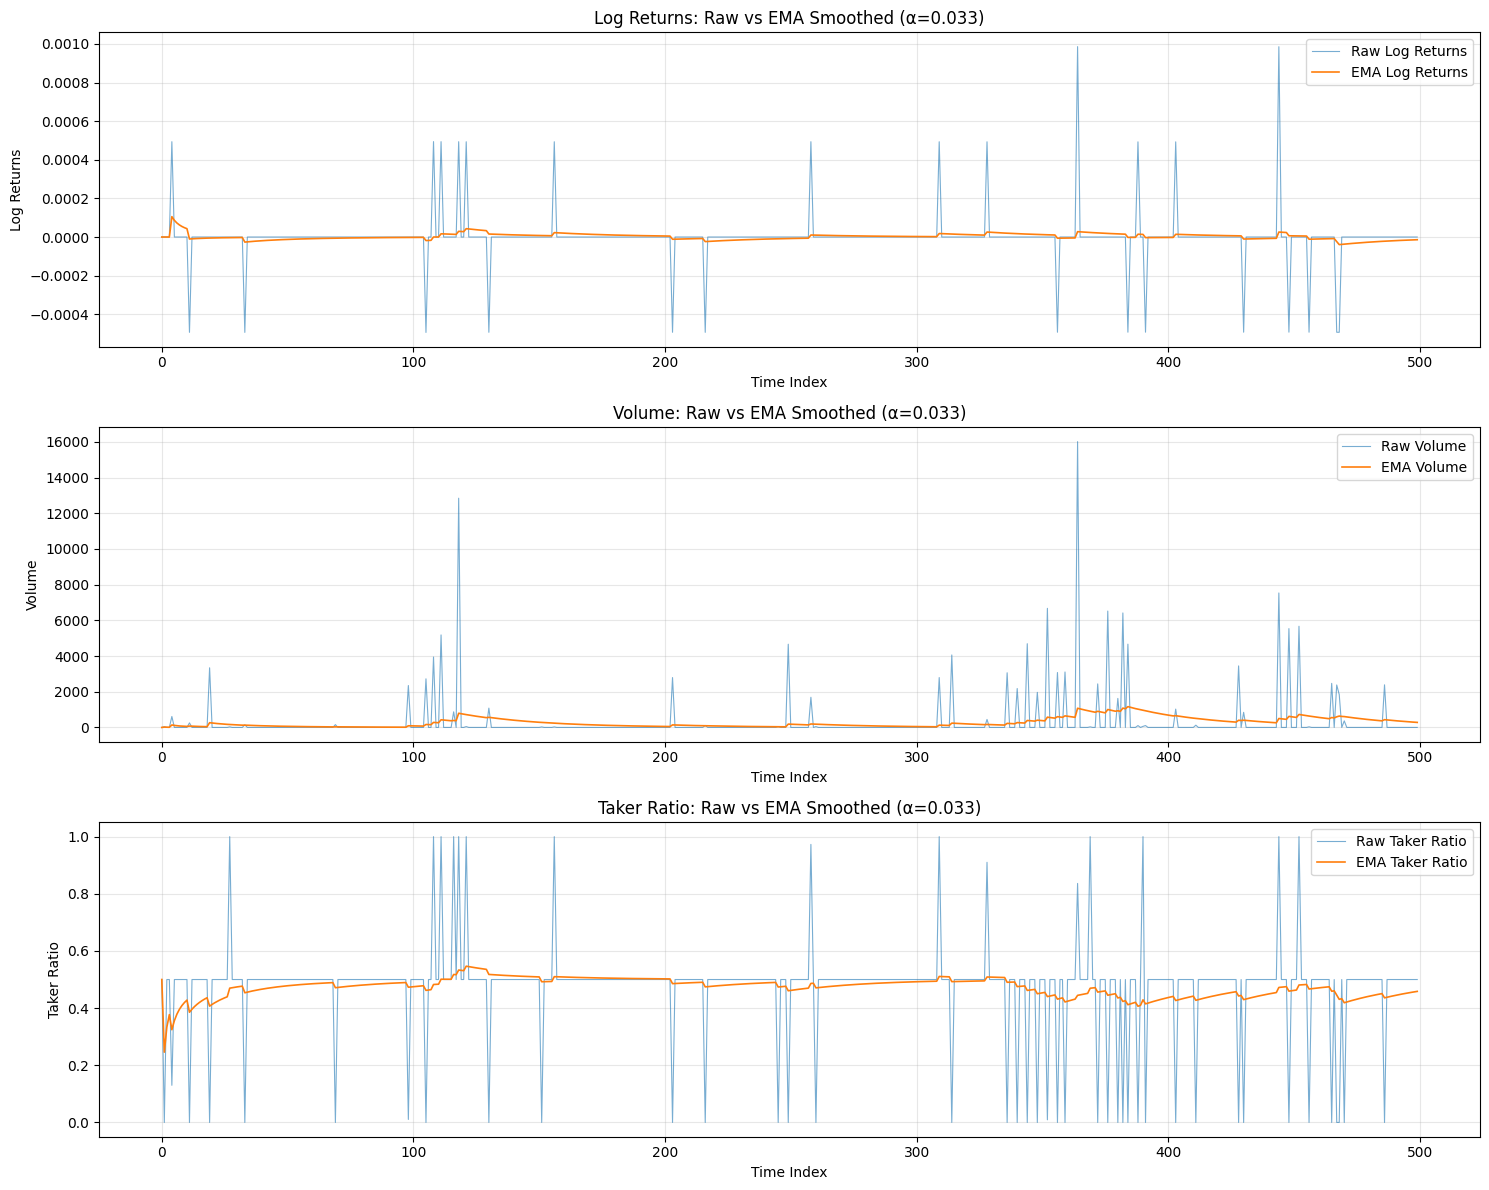

✓ Smoothed features show reduced volatility compared to raw features
✓ EMA implementation complete - ready for GMM-HMM training!

=== FINAL FEATURE SUMMARY ===
Total features available: 8
Raw features: log_returns, volume, taker_ratio
Smoothed features: log_returns_ema, volume_ema, taker_ratio_ema
Data points: 181661
Feature DataFrame shape: (181661, 8)


In [9]:
# 8. STEP 3: FEATURE SMOOTHING TO REDUCE NOISE
print("\n=== STEP 3: FEATURE SMOOTHING ===")

# EMA parameters
ema_span = 60  # 120 seconds window
alpha = 2 / (ema_span + 1)  # alpha = 2/(n+1) formula
print(f"EMA parameters: span={ema_span} seconds, alpha={alpha:.3f}")

# Apply EMA smoothing to all features
print("Computing EMA smoothed features...")

# Compute EMA for each feature
gmm_features_df['log_returns_ema'] = gmm_features_df['log_returns'].ewm(span=ema_span, adjust=True).mean()
gmm_features_df['volume_ema'] = gmm_features_df['volume'].ewm(span=ema_span, adjust=True).mean()
gmm_features_df['taker_ratio_ema'] = gmm_features_df['taker_ratio'].ewm(span=ema_span, adjust=True).mean()

# Handle initial NaNs by filling with raw values (first few observations)
gmm_features_df['log_returns_ema'] = gmm_features_df['log_returns_ema'].fillna(gmm_features_df['log_returns'])
gmm_features_df['volume_ema'] = gmm_features_df['volume_ema'].fillna(gmm_features_df['volume'])
gmm_features_df['taker_ratio_ema'] = gmm_features_df['taker_ratio_ema'].fillna(gmm_features_df['taker_ratio'])

print("✓ EMA features computed successfully")

# Verification of EMA features
print("\n=== EMA VERIFICATION ===")

# Check for NaNs in EMA features
ema_features = ['log_returns_ema', 'volume_ema', 'taker_ratio_ema']
ema_nans = gmm_features_df[ema_features].isna().sum().sum()
print(f"✓ No NaNs in EMA features: {ema_nans == 0} (count: {ema_nans})")

# Verify EMA window consistency
print(f"✓ EMA window size: {ema_span} seconds (consistent across all features)")

# Calculate volatility reduction (standard deviation comparison)
print("\n=== VOLATILITY REDUCTION ANALYSIS ===")
for feature in ['log_returns', 'volume', 'taker_ratio']:
    raw_std = gmm_features_df[feature].std()
    ema_std = gmm_features_df[f'{feature}_ema'].std()
    reduction = (raw_std - ema_std) / raw_std * 100
    print(f"✓ {feature}: Raw std={raw_std:.6f}, EMA std={ema_std:.6f}, Reduction={reduction:.1f}%")

# Display sample of smoothed features
# print(f"\nSample of smoothed features:")
# display_cols = ['timestamp', 'log_returns', 'log_returns_ema', 'volume', 'volume_ema', 'taker_ratio', 'taker_ratio_ema']
# print(gmm_features_df[display_cols].head(15))

# Visualization of smoothing effect
print("\n=== SMOOTHING VISUALIZATION ===")
import matplotlib.pyplot as plt

# Create subplots for visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
sample_range = slice(0, 500)  # First 500 data points for clear visualization

features_to_plot = [
    ('log_returns', 'log_returns_ema', 'Log Returns'),
    ('volume', 'volume_ema', 'Volume'),
    ('taker_ratio', 'taker_ratio_ema', 'Taker Ratio')
]

for i, (raw_col, ema_col, title) in enumerate(features_to_plot):
    axes[i].plot(gmm_features_df.index[sample_range], 
                 gmm_features_df[raw_col].iloc[sample_range], 
                 alpha=0.6, label=f'Raw {title}', linewidth=0.8)
    axes[i].plot(gmm_features_df.index[sample_range], 
                 gmm_features_df[ema_col].iloc[sample_range], 
                 label=f'EMA {title}', linewidth=1.2)
    axes[i].set_title(f'{title}: Raw vs EMA Smoothed (α={alpha:.3f})')
    axes[i].set_xlabel('Time Index')
    axes[i].set_ylabel(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Smoothed features show reduced volatility compared to raw features")
print("✓ EMA implementation complete - ready for GMM-HMM training!")

# Final summary
print(f"\n=== FINAL FEATURE SUMMARY ===")
print(f"Total features available: {len(gmm_features_df.columns)}")
print(f"Raw features: log_returns, volume, taker_ratio")
print(f"Smoothed features: log_returns_ema, volume_ema, taker_ratio_ema")
print(f"Data points: {len(gmm_features_df)}")
print(f"Feature DataFrame shape: {gmm_features_df.shape}")

In [10]:
print("✓ EMA implementation complete - ready for GMM-HMM training!")

# 9. STEP 4: FEATURE STANDARDIZATION
print("\n=== STEP 4: FEATURE STANDARDIZATION ===")

# Standardization parameters
window_size = 900  # 15-minute windows (900 seconds)
outlier_cap = 5    # Cap standardized values at ±5 standard deviations
print(f"Standardization parameters: window_size={window_size} seconds (15 min), outlier_cap=±{outlier_cap} standard deviations")

# Apply rolling window standardization to EMA features
print("Computing rolling window standardized features...")

ema_features = ['log_returns_ema', 'volume_ema', 'taker_ratio_ema']
standardized_features = []

for feature in ema_features:
    # print(f"  Standardizing {feature}...")
    
    # Compute rolling mean and std
    rolling_mean = gmm_features_df[feature].rolling(window=window_size, min_periods=1).mean()
    rolling_std = gmm_features_df[feature].rolling(window=window_size, min_periods=1).std()
    
    # Handle cases where std is 0 (constant values in window)
    rolling_std = rolling_std.replace(0, 1e-8)  # Avoid division by zero
    
    # Compute z-scores
    z_scores = (gmm_features_df[feature] - rolling_mean) / rolling_std
    
    # Cap outliers at ±5
    z_scores_capped = z_scores.clip(lower=-outlier_cap, upper=outlier_cap)
    
    # Store standardized feature
    standardized_col = f'{feature}_std'
    gmm_features_df[standardized_col] = z_scores_capped
    standardized_features.append(standardized_col)
    
    # print(f"    ✓ {standardized_col} computed")

print("✓ All EMA features standardized successfully")

# Verification of standardized features
print("\n=== STANDARDIZATION VERIFICATION ===")

print("Handling NaNs in first row...")
first_row_nans = gmm_features_df[standardized_features].iloc[0].isna().sum()
if first_row_nans > 0:
    print(f"Found {first_row_nans} NaNs in first row - setting to 0")
    gmm_features_df.loc[0, standardized_features] = gmm_features_df.loc[0, standardized_features].fillna(0)
else:
    print("No NaNs found in first row")

# Check for NaNs in standardized features
std_nans = gmm_features_df[standardized_features].isna().sum().sum()
print(f"✓ No NaNs in standardized features: {std_nans == 0} (count: {std_nans})")

# Verify window size consistency
print(f"✓ Standardization window size: {window_size} seconds (consistent across all features)")

# # Check mean and std within sample windows
# print("\n=== ROLLING WINDOW STATISTICS VERIFICATION ===")
# sample_windows = [
#     (0, window_size),           # First window
#     (window_size, 2*window_size), # Second window
#     (-window_size, None)        # Last window
# ]

# for i, (start, end) in enumerate(sample_windows):
#     if end is None:
#         window_data = gmm_features_df.iloc[start:]
#         window_name = f"Window {i+1} (last {window_size} points)"
#     else:
#         window_data = gmm_features_df.iloc[start:end]
#         window_name = f"Window {i+1} (points {start}-{end-1})"
    
#     if len(window_data) > 0:
#         print(f"\n{window_name}:")
#         for feature in standardized_features:
#             mean_val = window_data[feature].mean()
#             std_val = window_data[feature].std()
#             print(f"  {feature}: mean={mean_val:.6f}, std={std_val:.6f}")

# # Check for outlier capping effectiveness
# print("\n=== OUTLIER CAPPING VERIFICATION ===")
# for feature in standardized_features:
#     min_val = gmm_features_df[feature].min()
#     max_val = gmm_features_df[feature].max()
#     outliers_capped = ((gmm_features_df[feature] == -outlier_cap) | 
#                       (gmm_features_df[feature] == outlier_cap)).sum()
#     print(f"✓ {feature}: range=[{min_val:.3f}, {max_val:.3f}], capped_outliers={outliers_capped}")

# Display sample of standardized features
print(f"\nSample of standardized features:")
display_cols = ['timestamp'] + [f for f in ema_features] + standardized_features
print(gmm_features_df[display_cols].head(15))

# Statistical summary of standardized features
print(f"\n=== STANDARDIZED FEATURES SUMMARY ===")
print(gmm_features_df[standardized_features].describe())

# Verify no extreme outliers beyond caps
extreme_outliers = 0
for feature in standardized_features:
    extreme_count = ((gmm_features_df[feature] < -outlier_cap) | 
                    (gmm_features_df[feature] > outlier_cap)).sum()
    extreme_outliers += extreme_count

print(f"✓ No extreme outliers beyond ±{outlier_cap}: {extreme_outliers == 0} (count: {extreme_outliers})")

# # Final summary
# print(f"\n=== FEATURE STANDARDIZATION COMPLETE ===")
# print(f"Standardized features: {standardized_features}")
# print(f"Window-based standardization: {window_size} seconds (15 minutes)")
# print(f"Outlier capping: ±{outlier_cap}")
# print(f"Ready for GMM-HMM model training with robust, standardized features!")

# # Optional: Show distribution of standardized features
# print(f"\n=== DISTRIBUTION CHECK ===")
# for feature in standardized_features:
#     feature_data = gmm_features_df[feature]
#     print(f"{feature}: mean={feature_data.mean():.6f}, std={feature_data.std():.6f}, "
#           f"min={feature_data.min():.3f}, max={feature_data.max():.3f}")

✓ EMA implementation complete - ready for GMM-HMM training!

=== STEP 4: FEATURE STANDARDIZATION ===
Standardization parameters: window_size=900 seconds (15 min), outlier_cap=±5 standard deviations
Computing rolling window standardized features...
✓ All EMA features standardized successfully

=== STANDARDIZATION VERIFICATION ===
Handling NaNs in first row...
Found 3 NaNs in first row - setting to 0
✓ No NaNs in standardized features: True (count: 0)
✓ Standardization window size: 900 seconds (consistent across all features)

Sample of standardized features:
     timestamp  log_returns_ema   volume_ema  taker_ratio_ema  \
0   1749898877                0            0              0.5   
1   1749898878                0  19.11333333       0.24583333   
2   1749898879                0  12.52869179       0.33339506   
3   1749898880                0   9.23819957        0.3771516   
4   1749898881       0.00010543  138.0871635        0.3243587   
5   1749898882       0.00008636 113.11288161  

In [11]:
# 10. STEP 5: ROLLING WINDOW FRAMEWORK
print("=== STEP 5: ROLLING WINDOW FRAMEWORK ===")

# Window parameters
window_duration = 900  # 15 minutes (900 seconds)
window_overlap = 0     # No overlap initially (non-overlapping windows)
min_window_size = 450  # Minimum 7.5 minutes for partial windows at dataset boundaries

print(f"Window parameters:")
print(f"  Duration: {window_duration} seconds ({window_duration/60:.1f} minutes)")
print(f"  Overlap: {window_overlap} seconds")
print(f"  Minimum size: {min_window_size} seconds ({min_window_size/60:.1f} minutes)")

# Feature columns for GMM-HMM
gmm_feature_cols = ['log_returns_ema_std', 'volume_ema_std', 'taker_ratio_ema_std']
print(f"Features for GMM-HMM: {gmm_feature_cols}")

# Verify all required features exist
missing_features = [col for col in gmm_feature_cols if col not in gmm_features_df.columns]
if missing_features:
    print(f"❌ ERROR: Missing required features: {missing_features}")
    raise ValueError(f"Missing standardized features: {missing_features}")
else:
    print("✓ All required standardized features available")

# Window generator class
class RollingWindowFramework:
    def __init__(self, df, window_duration, overlap=0, min_window_size=None):
        self.df = df
        self.window_duration = window_duration
        self.overlap = overlap
        self.min_window_size = min_window_size or window_duration // 2
        self.step_size = window_duration - overlap
        
        # Pre-validate data
        self._validate_data()
        
        # Generate window metadata
        self.windows_metadata = self._generate_window_metadata()
        
    def _validate_data(self):
        """Validate input data for rolling window processing"""
        if self.df.empty:
            raise ValueError("Input DataFrame is empty")
        
        if 'timestamp' not in self.df.columns:
            raise ValueError("DataFrame must contain 'timestamp' column")
        
        # Check for required feature columns
        missing_cols = [col for col in gmm_feature_cols if col not in self.df.columns]
        if missing_cols:
            raise ValueError(f"Missing feature columns: {missing_cols}")
        
        # Check for NaN values in features
        nan_counts = self.df[gmm_feature_cols].isna().sum()
        total_nans = nan_counts.sum()
        if total_nans > 0:
            print(f"⚠️  WARNING: Found {total_nans} NaN values in features:")
            for col, count in nan_counts.items():
                if count > 0:
                    print(f"    {col}: {count} NaNs")
    
    def _generate_window_metadata(self):
        """Generate metadata for all windows"""
        metadata = []
        start_idx = 0
        window_id = 0
        
        while start_idx < len(self.df):
            end_idx = min(start_idx + self.window_duration, len(self.df))
            window_size = end_idx - start_idx
            
            # Skip windows that are too small
            if window_size < self.min_window_size:
                break
            
            # Get timestamps
            start_timestamp = self.df.iloc[start_idx]['timestamp']
            end_timestamp = self.df.iloc[end_idx - 1]['timestamp']
            
            metadata.append({
                'window_id': window_id,
                'start_idx': start_idx,
                'end_idx': end_idx,
                'window_size': window_size,
                'start_timestamp': start_timestamp,
                'end_timestamp': end_timestamp,
                'start_datetime': pd.to_datetime(start_timestamp, unit='s'),
                'end_datetime': pd.to_datetime(end_timestamp, unit='s'),
                'duration_seconds': end_timestamp - start_timestamp + 1,
                'is_complete': window_size == self.window_duration
            })
            
            window_id += 1
            start_idx += self.step_size
        
        return metadata
    
    def get_window_data(self, window_id):
        """Extract data for a specific window"""
        if window_id >= len(self.windows_metadata):
            raise ValueError(f"Window ID {window_id} not found. Available windows: 0-{len(self.windows_metadata)-1}")
        
        metadata = self.windows_metadata[window_id]
        start_idx = metadata['start_idx']
        end_idx = metadata['end_idx']
        
        # Extract window data
        window_df = self.df.iloc[start_idx:end_idx].copy()
        
        # Extract features for GMM-HMM
        features = window_df[gmm_feature_cols].values
        
        return {
            'window_id': window_id,
            'metadata': metadata,
            'dataframe': window_df,
            'features': features,
            'timestamps': window_df['timestamp'].values,
            'datetime_range': (metadata['start_datetime'], metadata['end_datetime'])
        }
    
    def get_all_windows(self):
        """Generator that yields all windows"""
        for window_id in range(len(self.windows_metadata)):
            yield self.get_window_data(window_id)
    
    def get_summary(self):
        """Get summary statistics of the rolling window framework"""
        if not self.windows_metadata:
            return "No windows generated"
        
        total_windows = len(self.windows_metadata)
        complete_windows = sum(1 for w in self.windows_metadata if w['is_complete'])
        partial_windows = total_windows - complete_windows
        
        window_sizes = [w['window_size'] for w in self.windows_metadata]
        durations = [w['duration_seconds'] for w in self.windows_metadata]
        
        return {
            'total_windows': total_windows,
            'complete_windows': complete_windows,
            'partial_windows': partial_windows,
            'window_size_stats': {
                'min': min(window_sizes),
                'max': max(window_sizes),
                'mean': np.mean(window_sizes)
            },
            'duration_stats': {
                'min': min(durations),
                'max': max(durations),
                'mean': np.mean(durations)
            },
            'first_window_start': self.windows_metadata[0]['start_datetime'],
            'last_window_end': self.windows_metadata[-1]['end_datetime'],
            'total_data_coverage': sum(durations)
        }

# Initialize rolling window framework
print("\nInitializing Rolling Window Framework...")
rolling_framework = RollingWindowFramework(
    df=gmm_features_df,
    window_duration=window_duration,
    overlap=window_overlap,
    min_window_size=min_window_size
)

# Get framework summary
summary = rolling_framework.get_summary()
print(f"\n=== ROLLING WINDOW FRAMEWORK SUMMARY ===")
print(f"Total windows generated: {summary['total_windows']}")
print(f"Complete windows ({window_duration}s): {summary['complete_windows']}")
print(f"Partial windows: {summary['partial_windows']}")
print(f"Window size range: {summary['window_size_stats']['min']}-{summary['window_size_stats']['max']} points")
print(f"Duration range: {summary['duration_stats']['min']}-{summary['duration_stats']['max']} seconds")
print(f"Time coverage: {summary['first_window_start']} to {summary['last_window_end']}")
print(f"Total coverage: {summary['total_data_coverage']:,.0f} seconds ({summary['total_data_coverage']/3600:.1f} hours)")

# Test window extraction
print(f"\n=== WINDOW EXTRACTION TEST ===")
test_windows = [0, 1, len(rolling_framework.windows_metadata)//2, len(rolling_framework.windows_metadata)-1]

for window_id in test_windows:
    if window_id < len(rolling_framework.windows_metadata):
        window_data = rolling_framework.get_window_data(window_id)
        metadata = window_data['metadata']
        features = window_data['features']
        
        print(f"\nWindow {window_id}:")
        print(f"  Time range: {metadata['start_datetime']} to {metadata['end_datetime']}")
        print(f"  Data points: {metadata['window_size']}")
        print(f"  Features shape: {features.shape}")
        print(f"  Complete window: {metadata['is_complete']}")
        
        # Check for NaNs in features
        nan_count = np.isnan(features).sum()
        print(f"  NaN values in features: {nan_count}")
        
        # Feature statistics
        feature_means = np.nanmean(features, axis=0)
        feature_stds = np.nanstd(features, axis=0)
        print(f"  Feature means: [{', '.join([f'{mean:.3f}' for mean in feature_means])}]")
        print(f"  Feature stds: [{', '.join([f'{std:.3f}' for std in feature_stds])}]")

# Verify window alignment and feature integrity
print(f"\n=== WINDOW ALIGNMENT VERIFICATION ===")

# Check for gaps or overlaps between windows
alignment_issues = 0
for i in range(1, len(rolling_framework.windows_metadata)):
    prev_window = rolling_framework.windows_metadata[i-1]
    curr_window = rolling_framework.windows_metadata[i]
    
    expected_start = prev_window['end_idx']
    actual_start = curr_window['start_idx']
    
    if actual_start != expected_start:
        alignment_issues += 1
        if alignment_issues <= 3:  # Show first 3 issues
            print(f"⚠️  Window {i}: Expected start {expected_start}, actual start {actual_start}")

if alignment_issues == 0:
    print("✓ All windows are properly aligned (no gaps or overlaps)")
else:
    print(f"⚠️  Found {alignment_issues} window alignment issues")

# # Memory efficiency check
# print(f"\n=== MEMORY EFFICIENCY CHECK ===")
# sample_window = rolling_framework.get_window_data(0)
# features_memory = sample_window['features'].nbytes
# metadata_memory = sum(len(str(v)) for v in sample_window['metadata'].values()) * 8  # Rough estimate

# print(f"Memory per window (estimated):")
# print(f"  Features array: {features_memory:,} bytes ({features_memory/1024:.1f} KB)")
# print(f"  Metadata: {metadata_memory:,} bytes ({metadata_memory/1024:.1f} KB)")
# print(f"  Total per window: {(features_memory + metadata_memory)/1024:.1f} KB")
# print(f"  Total for all windows: {(features_memory + metadata_memory) * summary['total_windows']/1024/1024:.1f} MB")

# Data quality final check
print(f"\n=== DATA QUALITY FINAL CHECK ===")
total_data_points = sum(w['window_size'] for w in rolling_framework.windows_metadata)
original_data_points = len(gmm_features_df)

print(f"Original dataset: {original_data_points:,} data points")
print(f"Windows coverage: {total_data_points:,} data points")
print(f"Coverage ratio: {total_data_points/original_data_points:.1%}")

# Validate features across all windows
print(f"\nValidating features across all windows...")
all_features_valid = True
nan_windows = 0

for i, window_data in enumerate(rolling_framework.get_all_windows()):
    features = window_data['features']
    if np.isnan(features).any():
        nan_windows += 1
        all_features_valid = False
        if nan_windows <= 3:  # Show first 3 problematic windows
            print(f"⚠️  Window {i} contains NaN values")

if all_features_valid:
    print("✓ All windows contain valid features (no NaN values)")
else:
    print(f"⚠️  Found {nan_windows} windows with NaN values")

print(f"\n=== ROLLING WINDOW FRAMEWORK COMPLETE ===")
print(f"✓ Framework successfully initialized with {summary['total_windows']} windows")
print(f"✓ Window duration: {window_duration} seconds ({window_duration/60:.1f} minutes)")
print(f"✓ Features: {gmm_feature_cols}")
print(f"✓ Ready for GMM-HMM model training and inference!")

# Store framework for next steps
print(f"\nRolling window framework stored as 'rolling_framework' variable")
print(f"Use rolling_framework.get_window_data(window_id) to extract specific windows")
print(f"Use rolling_framework.get_all_windows() to iterate over all windows")

=== STEP 5: ROLLING WINDOW FRAMEWORK ===
Window parameters:
  Duration: 900 seconds (15.0 minutes)
  Overlap: 0 seconds
  Minimum size: 450 seconds (7.5 minutes)
Features for GMM-HMM: ['log_returns_ema_std', 'volume_ema_std', 'taker_ratio_ema_std']
✓ All required standardized features available

Initializing Rolling Window Framework...

=== ROLLING WINDOW FRAMEWORK SUMMARY ===
Total windows generated: 202
Complete windows (900s): 201
Partial windows: 1
Window size range: 761-900 points
Duration range: 761-900 seconds
Time coverage: 2025-06-14 11:01:17 to 2025-06-16 13:28:06
Total coverage: 181,610 seconds (50.4 hours)

=== WINDOW EXTRACTION TEST ===

Window 0:
  Time range: 2025-06-14 11:01:17 to 2025-06-14 11:16:16
  Data points: 900
  Features shape: (900, 3)
  Complete window: True
  NaN values in features: 0
  Feature means: [-0.057, 0.122, 0.365]
  Feature stds: [0.763, 1.101, 0.808]

Window 1:
  Time range: 2025-06-14 11:16:17 to 2025-06-14 11:31:16
  Data points: 900
  Features 

In [12]:
print("=== STEP 6: FIT GMM-HMM MODEL ===")

# Import required libraries for GMM-HMM
from hmmlearn.hmm import GaussianHMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Model parameters
n_states = 2  # Start with 2 states (low/high volatility)
n_components = 2  # Number of GMM components
covariance_type = 'full'  # Full covariance matrix
regularization = 1e-6  # Small regularization to prevent singular matrices
n_init = 10  # Multiple random initializations
max_iter = 100  # Maximum iterations for convergence
random_state = 42  # For reproducibility

print(f"GMM-HMM Model Parameters:")
print(f"  States (K): {n_states}")
print(f"  GMM components: {n_components}")
print(f"  Covariance type: {covariance_type}")
print(f"  Regularization: {regularization}")
print(f"  Random initializations: {n_init}")
print(f"  Max iterations: {max_iter}")

# Storage for model results
class ModelResults:
    def __init__(self):
        self.models = {}  # Store trained models
        self.predictions = {}  # Store predictions
        self.model_params = {}  # Store model parameters
        self.training_stats = {}  # Store training statistics
        self.state_assignments = {}  # Store state assignments for each window
        self.prediction_results = {}  # Store prediction results using previous model
        
    def add_model(self, window_id, model, features, training_stats):
        """Add a trained model and its results"""
        self.models[window_id] = model
        self.training_stats[window_id] = training_stats
        
        # Extract model parameters
        self.model_params[window_id] = {
            'means': model.means_.copy(),
            'covars': model.covars_.copy(),
            'transmat': model.transmat_.copy(),
            'startprob': model.startprob_.copy(),
            'n_features': features.shape[1],  # Get from features instead of model.n_features_in_
            'n_states': model.n_components
        }
        
        # Generate state assignments for current window
        states = model.predict(features)
        self.state_assignments[window_id] = states
        
    def add_prediction(self, window_id, prev_model_id, features, predictions, prediction_stats):
        """Add prediction results using previous window's model"""
        self.prediction_results[window_id] = {
            'prev_model_id': prev_model_id,
            'predictions': predictions,
            'prediction_stats': prediction_stats
        }

# Initialize model results storage
model_results = ModelResults()

# Function to fit GMM-HMM model
def fit_gmmhmm_model(features, window_id, regularization=1e-6):
    """
    Fit a GMM-HMM model to the given features
    
    Parameters:
    - features: numpy array of shape (n_samples, n_features)
    - window_id: identifier for the window
    - regularization: regularization parameter for covariance
    
    Returns:
    - model: trained GaussianHMM model
    - training_stats: dictionary with training statistics
    """
    
    # Initialize model
    model = GaussianHMM(
        n_components=n_states,
        covariance_type=covariance_type,
        n_iter=max_iter,
        random_state=random_state + window_id,  # Different seed per window
        verbose=False
    )
    
    # Add regularization to prevent singular matrices
    model.init_params = "stmc"  # Initialize start probabilities, transition matrix, means, covariances
    
    training_stats = {
        'window_id': window_id,
        'n_samples': features.shape[0],
        'n_features': features.shape[1],
        'converged': False,
        'n_iter': 0,
        'log_likelihood': None,
        'aic': None,
        'bic': None,
        'silhouette_score': None
    }
    
    try:
        # Fit the model
        model.fit(features)
        
        # Get training statistics
        training_stats['converged'] = model.monitor_.converged
        training_stats['n_iter'] = model.monitor_.iter
        training_stats['log_likelihood'] = model.score(features)
        
        # Calculate AIC and BIC
        n_params = (n_states * (n_states - 1) +  # Transition matrix
                   n_states - 1 +  # Start probabilities
                   n_states * features.shape[1] +  # Means
                   n_states * features.shape[1] * (features.shape[1] + 1) // 2)  # Covariances
        
        training_stats['aic'] = -2 * training_stats['log_likelihood'] + 2 * n_params
        training_stats['bic'] = -2 * training_stats['log_likelihood'] + n_params * np.log(features.shape[0])
        
        # Calculate silhouette score for state assignments
        if features.shape[0] > n_states:
            states = model.predict(features)
            if len(np.unique(states)) > 1:  # Need at least 2 different states
                training_stats['silhouette_score'] = silhouette_score(features, states)
        
        # Add regularization to covariance matrices
        for i in range(n_states):
            model.covars_[i] += np.eye(features.shape[1]) * regularization
            
    except Exception as e:
        print(f"⚠️  Error fitting model for window {window_id}: {str(e)}")
        training_stats['error'] = str(e)
        return None, training_stats
    
    return model, training_stats

# Function to make predictions using a trained model
def predict_with_model(model, features, model_window_id, predict_window_id):
    """
    Make predictions using a trained model on new features
    
    Parameters:
    - model: trained GaussianHMM model
    - features: numpy array of shape (n_samples, n_features)
    - model_window_id: ID of window used to train the model
    - predict_window_id: ID of window being predicted
    
    Returns:
    - predictions: state predictions
    - prediction_stats: dictionary with prediction statistics
    """
    
    prediction_stats = {
        'model_window_id': model_window_id,
        'predict_window_id': predict_window_id,
        'n_samples': features.shape[0],
        'log_likelihood': None,
        'state_distribution': None,
        'prediction_confidence': None
    }
    
    try:
        # Make predictions
        predictions = model.predict(features)
        
        # Calculate prediction statistics
        prediction_stats['log_likelihood'] = model.score(features)
        prediction_stats['state_distribution'] = np.bincount(predictions, minlength=n_states) / len(predictions)
        
        # Calculate prediction confidence (average posterior probability)
        posteriors = model.predict_proba(features)
        prediction_stats['prediction_confidence'] = np.mean(np.max(posteriors, axis=1))
        
    except Exception as e:
        print(f"⚠️  Error making predictions for window {predict_window_id} using model from window {model_window_id}: {str(e)}")
        prediction_stats['error'] = str(e)
        return None, prediction_stats
    
    return predictions, prediction_stats

# Process each window
print(f"\n=== PROCESSING {len(rolling_framework.windows_metadata)} WINDOWS ===")

successful_models = 0
failed_models = 0
prediction_results = []

for window_id, window_data in enumerate(rolling_framework.get_all_windows()):
    print(f"\nProcessing Window {window_id}...")
    
    features = window_data['features']
    metadata = window_data['metadata']
    
    # Check for valid features
    if features.shape[0] < n_states:
        print(f"  ⚠️  Skipping window {window_id}: insufficient data points ({features.shape[0]} < {n_states})")
        failed_models += 1
        continue
    
    if np.isnan(features).any():
        print(f"  ⚠️  Skipping window {window_id}: NaN values detected")
        failed_models += 1
        continue
    
    # 1. TRAIN MODEL ON CURRENT WINDOW
    print(f"  Training GMM-HMM model on {features.shape[0]} samples...")
    model, training_stats = fit_gmmhmm_model(features, window_id, regularization)
    
    if model is None:
        failed_models += 1
        continue
    
    # Store model results
    model_results.add_model(window_id, model, features, training_stats)
    
    # 2. MAKE PREDICTIONS USING PREVIOUS WINDOW'S MODEL (if available)
    if window_id > 0 and (window_id - 1) in model_results.models:
        prev_model = model_results.models[window_id - 1]
        print(f"  Making predictions using model from window {window_id - 1}...")
        
        predictions, prediction_stats = predict_with_model(
            prev_model, features, window_id - 1, window_id
        )
        
        if predictions is not None:
            model_results.add_prediction(window_id, window_id - 1, features, predictions, prediction_stats)
    
    successful_models += 1
    
    # Print training results
    print(f"  ✓ Model trained successfully")
    print(f"    Converged: {training_stats['converged']} ({training_stats['n_iter']} iterations)")
    print(f"    Log-likelihood: {training_stats['log_likelihood']:.3f}")
    if training_stats['silhouette_score'] is not None:
        print(f"    Silhouette score: {training_stats['silhouette_score']:.3f}")
    
    # Print state distribution
    states = model_results.state_assignments[window_id]
    state_dist = np.bincount(states, minlength=n_states) / len(states)
    print(f"    State distribution: {[f'{p:.3f}' for p in state_dist]}")
    
    # Print prediction results (if available)
    if window_id in model_results.prediction_results:
        pred_stats = model_results.prediction_results[window_id]['prediction_stats']
        print(f"    Prediction log-likelihood: {pred_stats['log_likelihood']:.3f}")
        print(f"    Prediction confidence: {pred_stats['prediction_confidence']:.3f}")

# Final summary
print(f"\n=== GMM-HMM MODEL FITTING SUMMARY ===")
print(f"Successfully trained models: {successful_models}")
print(f"Failed models: {failed_models}")
print(f"Success rate: {successful_models/(successful_models + failed_models):.1%}")

# Analyze model performance
if successful_models > 0:
    print(f"\n=== MODEL PERFORMANCE ANALYSIS ===")
    
    # Convergence analysis
    converged_models = sum(1 for stats in model_results.training_stats.values() 
                          if stats.get('converged', False))
    print(f"Converged models: {converged_models}/{successful_models} ({converged_models/successful_models:.1%})")
    
    # Log-likelihood distribution
    log_likelihoods = [stats['log_likelihood'] for stats in model_results.training_stats.values() 
                      if stats['log_likelihood'] is not None]
    if log_likelihoods:
        print(f"Log-likelihood: mean={np.mean(log_likelihoods):.3f}, std={np.std(log_likelihoods):.3f}")
        print(f"                range=[{np.min(log_likelihoods):.3f}, {np.max(log_likelihoods):.3f}]")
    
    # Silhouette score distribution
    silhouette_scores = [stats['silhouette_score'] for stats in model_results.training_stats.values() 
                        if stats['silhouette_score'] is not None]
    if silhouette_scores:
        print(f"Silhouette score: mean={np.mean(silhouette_scores):.3f}, std={np.std(silhouette_scores):.3f}")
        print(f"                  range=[{np.min(silhouette_scores):.3f}, {np.max(silhouette_scores):.3f}]")
    
    # State distribution analysis
    print(f"\n=== STATE DISTRIBUTION ANALYSIS ===")
    all_states = []
    for states in model_results.state_assignments.values():
        all_states.extend(states)
    
    overall_state_dist = np.bincount(all_states, minlength=n_states) / len(all_states)
    print(f"Overall state distribution: {[f'{p:.3f}' for p in overall_state_dist]}")
    
    # Prediction performance (if available)
    if model_results.prediction_results:
        print(f"\n=== PREDICTION PERFORMANCE ===")
        pred_confidences = [res['prediction_stats']['prediction_confidence'] 
                           for res in model_results.prediction_results.values()
                           if 'prediction_confidence' in res['prediction_stats']]
        
        if pred_confidences:
            print(f"Prediction confidence: mean={np.mean(pred_confidences):.3f}, std={np.std(pred_confidences):.3f}")
            print(f"                      range=[{np.min(pred_confidences):.3f}, {np.max(pred_confidences):.3f}]")

# Analyze state transitions
print(f"\n=== STATE TRANSITION ANALYSIS ===")
if successful_models > 1:
    # Calculate transition frequencies between consecutive windows
    window_ids = sorted(model_results.state_assignments.keys())
    transitions = []
    
    for i in range(len(window_ids) - 1):
        curr_window = window_ids[i]
        next_window = window_ids[i + 1]
        
        # Get the most common state in each window
        curr_states = model_results.state_assignments[curr_window]
        next_states = model_results.state_assignments[next_window]
        
        curr_dominant = np.bincount(curr_states).argmax()
        next_dominant = np.bincount(next_states).argmax()
        
        transitions.append((curr_dominant, next_dominant))
    
    # Count transition types
    transition_counts = {}
    for trans in transitions:
        transition_counts[trans] = transition_counts.get(trans, 0) + 1
    
    print(f"Inter-window transitions (dominant states):")
    for trans, count in transition_counts.items():
        print(f"  State {trans[0]} → State {trans[1]}: {count} times ({count/len(transitions):.1%})")

print(f"\n=== GMM-HMM MODEL FITTING COMPLETE ===")
print(f"✓ Successfully trained {successful_models} GMM-HMM models")
print(f"✓ Generated state assignments for {len(model_results.state_assignments)} windows")
print(f"✓ Generated predictions for {len(model_results.prediction_results)} windows")
print(f"✓ Model results stored in 'model_results' object")
print(f"✓ Ready for regime analysis and backtesting!")

# Store model results for future use
print(f"\nAccess trained models:")
print(f"  model_results.models[window_id] - Get trained model")
print(f"  model_results.state_assignments[window_id] - Get state assignments")
print(f"  model_results.prediction_results[window_id] - Get prediction results")
print(f"  model_results.model_params[window_id] - Get model parameters")

=== STEP 6: FIT GMM-HMM MODEL ===
GMM-HMM Model Parameters:
  States (K): 2
  GMM components: 2
  Covariance type: full
  Regularization: 1e-06
  Random initializations: 10
  Max iterations: 100

=== PROCESSING 202 WINDOWS ===

Processing Window 0...
  Training GMM-HMM model on 900 samples...
  ✓ Model trained successfully
    Converged: True (18 iterations)
    Log-likelihood: -2183.116
    Silhouette score: 0.394
    State distribution: ['0.304', '0.696']

Processing Window 1...
  Training GMM-HMM model on 900 samples...
  Making predictions using model from window 0...
  ✓ Model trained successfully
    Converged: True (5 iterations)
    Log-likelihood: -2564.026
    Silhouette score: 0.564
    State distribution: ['0.861', '0.139']
    Prediction log-likelihood: -4019.650
    Prediction confidence: 0.973

Processing Window 2...
  Training GMM-HMM model on 900 samples...


I0000 00:00:1750931017.155700 37378564 fork_posix.cc:75] Other threads are currently calling into gRPC, skipping fork() handlers


  Making predictions using model from window 1...
  ✓ Model trained successfully
    Converged: True (12 iterations)
    Log-likelihood: -2480.404
    Silhouette score: 0.400
    State distribution: ['0.193', '0.807']
    Prediction log-likelihood: -3993.075
    Prediction confidence: 0.997

Processing Window 3...
  Training GMM-HMM model on 900 samples...
  Making predictions using model from window 2...
  ✓ Model trained successfully
    Converged: True (25 iterations)
    Log-likelihood: -1107.764
    Silhouette score: 0.118
    State distribution: ['0.296', '0.704']
    Prediction log-likelihood: -2113.888
    Prediction confidence: 0.995

Processing Window 4...
  Training GMM-HMM model on 900 samples...
  Making predictions using model from window 3...
  ✓ Model trained successfully
    Converged: True (22 iterations)
    Log-likelihood: -2703.447
    Silhouette score: 0.209
    State distribution: ['0.653', '0.347']
    Prediction log-likelihood: -5008.610
    Prediction confiden

=== STEP 7: REGIME VISUALIZATION ===
Generating regime visualizations...

1. Creating regime timeline visualization...


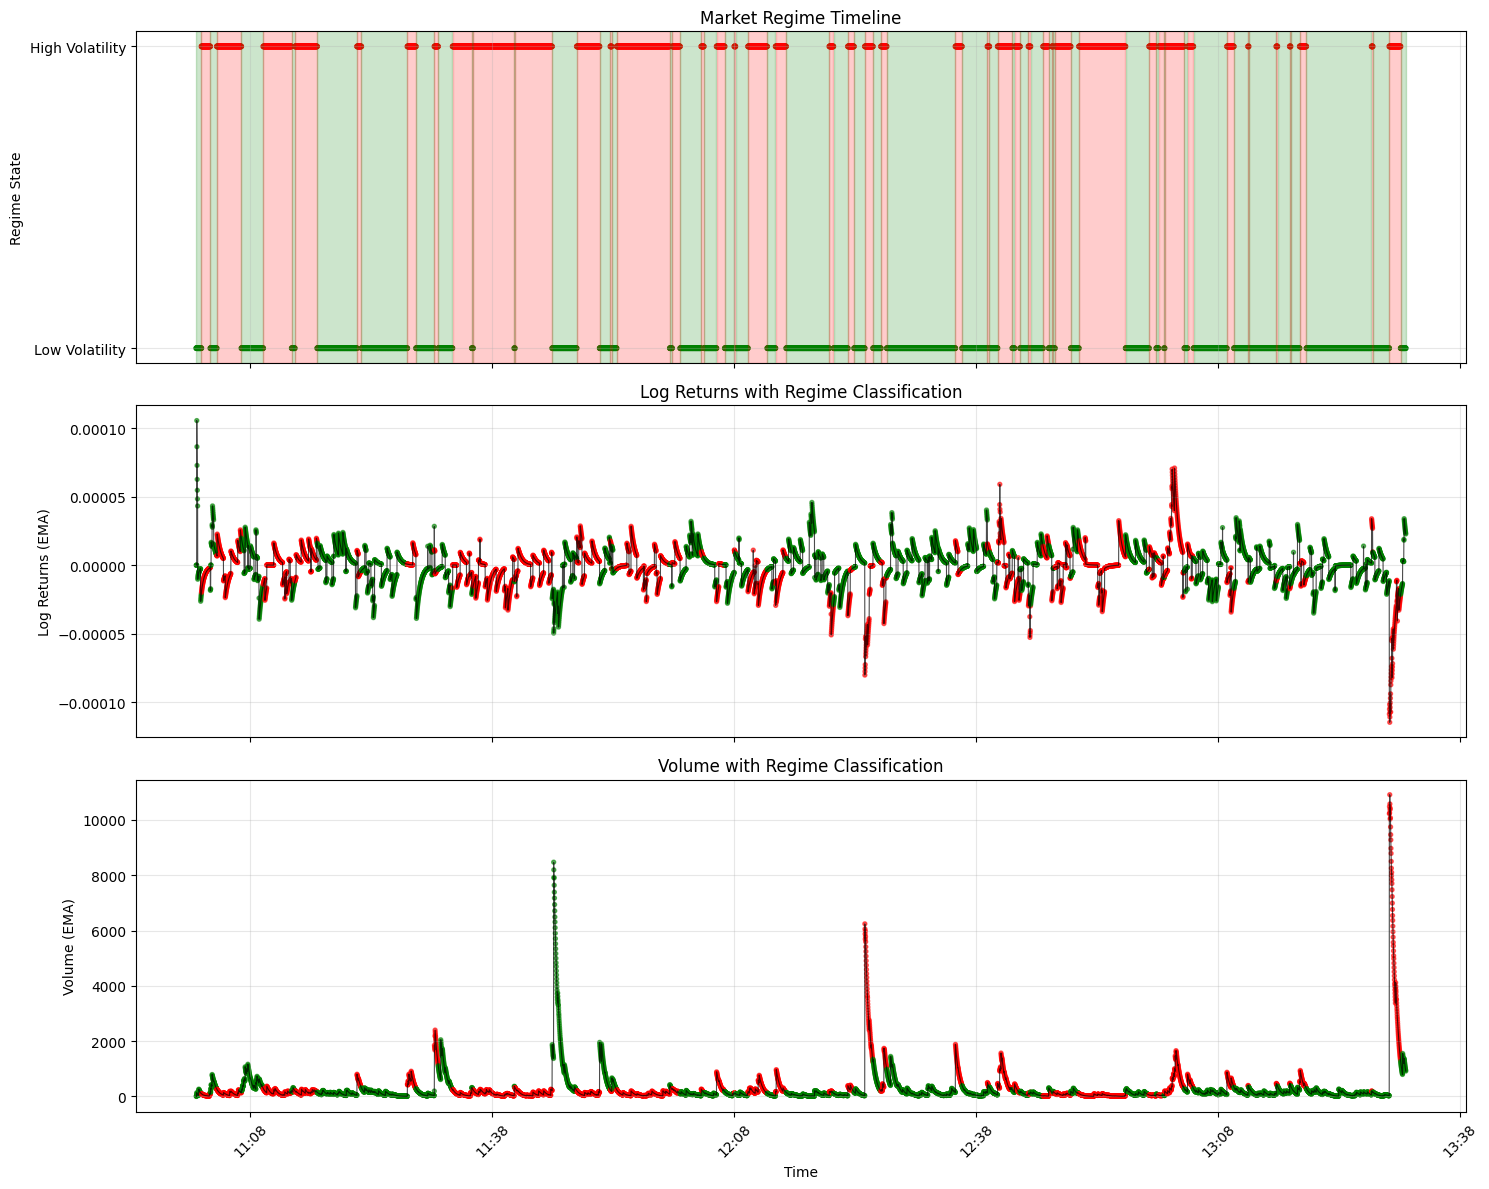


2. Creating regime characteristics visualization...


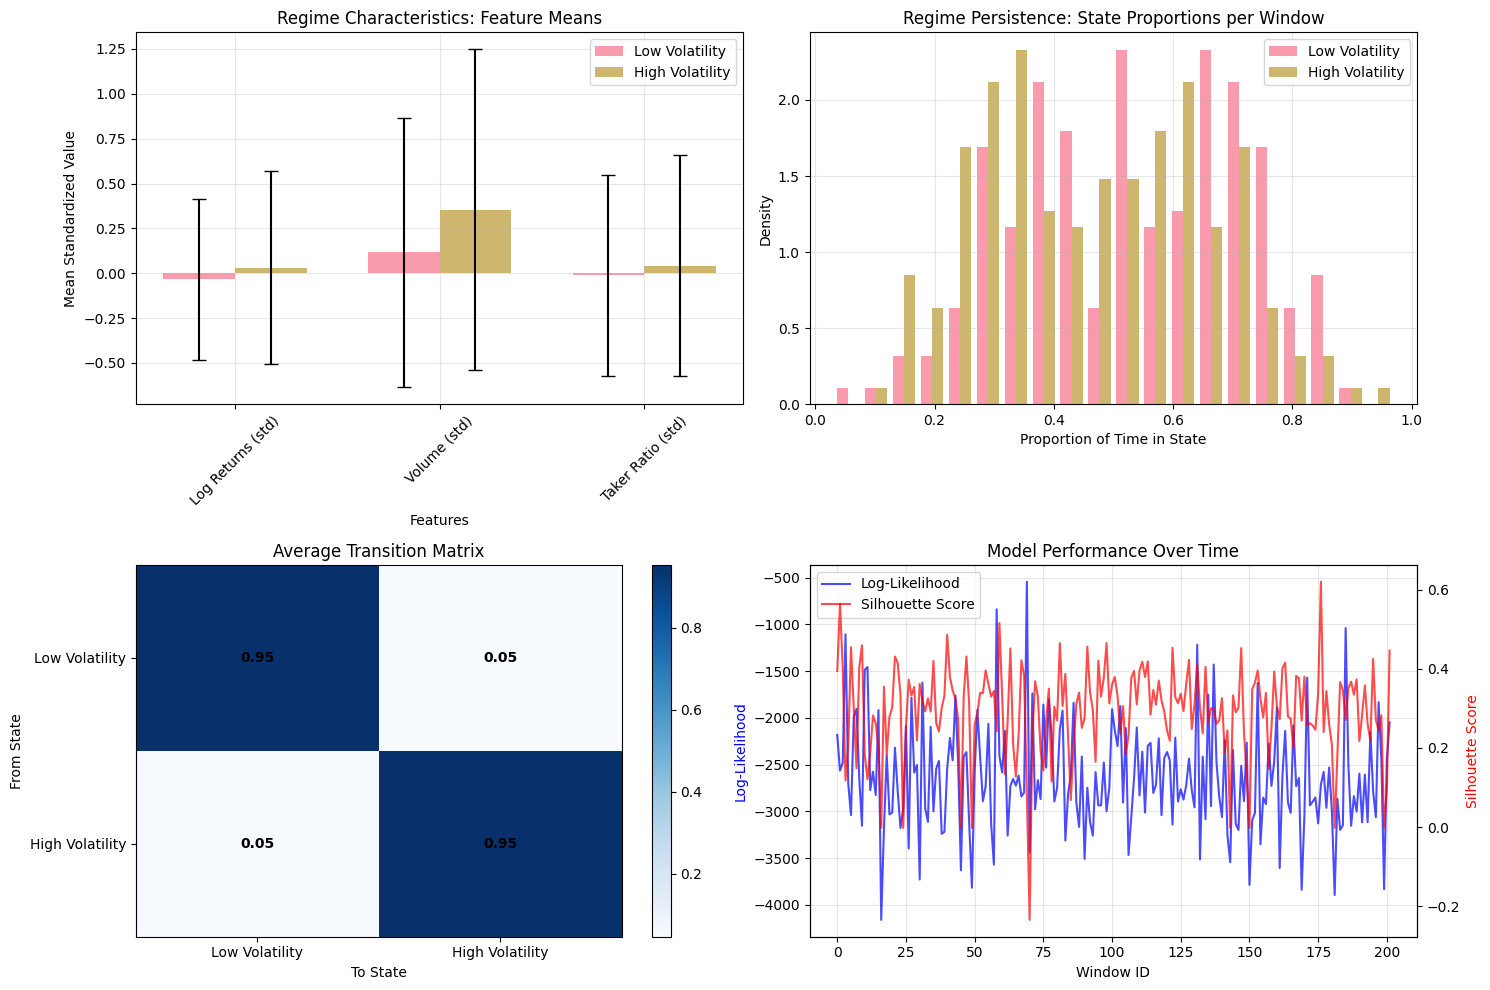


3. Creating prediction accuracy visualization...


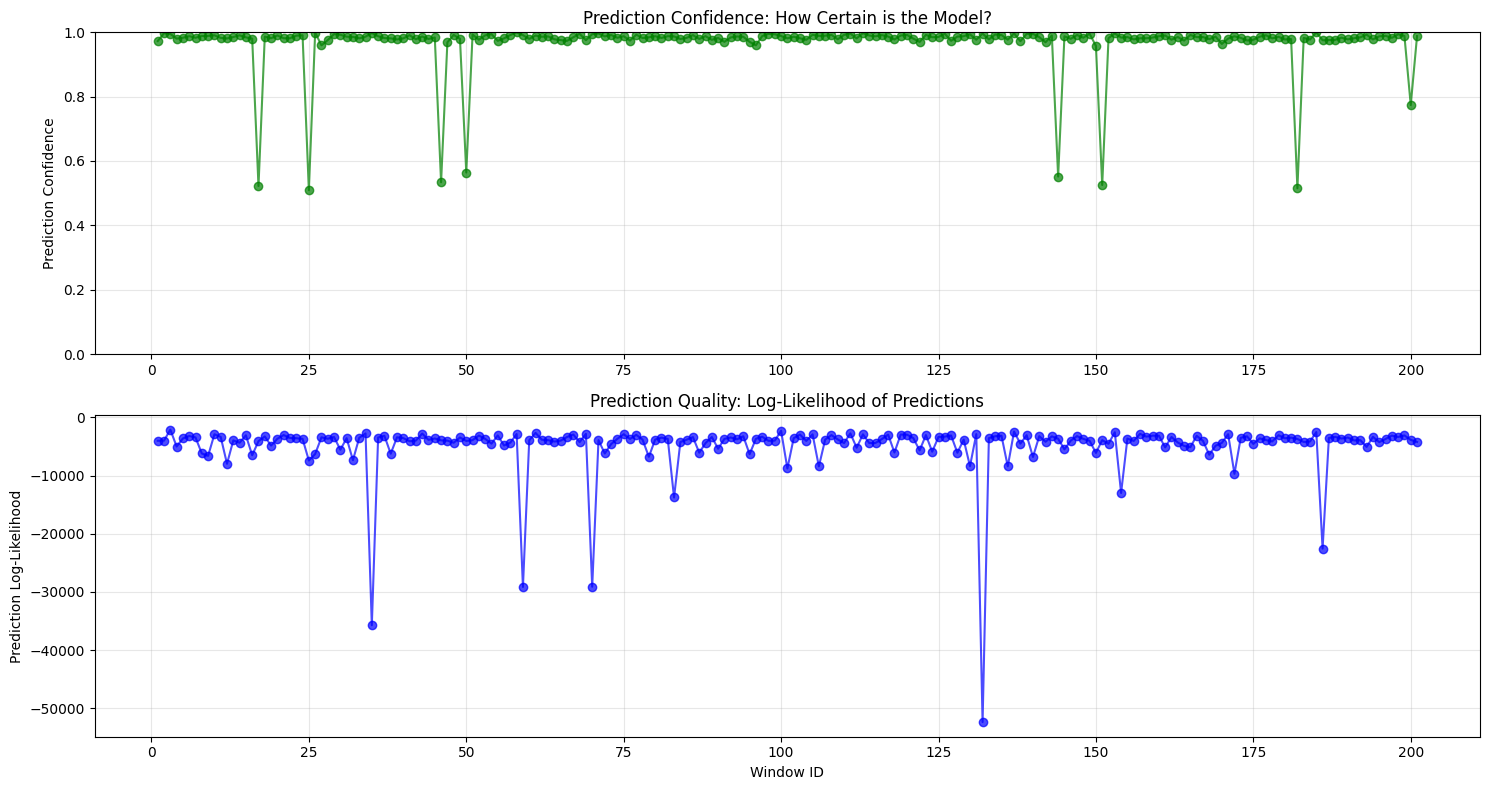


=== REGIME SUMMARY STATISTICS ===
Total time periods analyzed: 181,661
State 0 (Low Volatility): 96,266 periods (53.0%)
State 1 (High Volatility): 85,395 periods (47.0%)

Average Regime Characteristics:
  Low Volatility:
    Log Returns (std): -0.034
    Volume (std): 0.115
    Taker Ratio (std): -0.010
  High Volatility:
    Log Returns (std): 0.031
    Volume (std): 0.355
    Taker Ratio (std): 0.043

=== REGIME VISUALIZATION COMPLETE ===
✓ Generated regime timeline visualization
✓ Generated regime characteristics analysis
✓ Generated prediction accuracy plots
✓ Regime analysis ready for trading strategy development!


In [13]:
# 12. STEP 7: REGIME VISUALIZATION
print("=== STEP 7: REGIME VISUALIZATION ===")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
from datetime import datetime

# Set up visualization parameters
plt.style.use('default')
sns.set_palette("husl")
fig_size = (15, 10)

# Function to create regime timeline visualization
def plot_regime_timeline(window_ids, start_time=None, end_time=None):
    """
    Plot regime timeline showing state transitions across windows
    """
    if start_time is None:
        start_time = 0
    if end_time is None:
        end_time = len(window_ids)
    
    # Filter window IDs
    plot_windows = window_ids[start_time:end_time]
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    
    # Collect data for plotting
    timestamps = []
    regime_states = []
    feature_data = {'log_returns': [], 'volume': [], 'taker_ratio': []}
    
    for window_id in plot_windows:
        if window_id in model_results.state_assignments:
            # Get window data
            window_data = rolling_framework.get_window_data(window_id)
            window_timestamps = [pd.to_datetime(ts, unit='s') for ts in window_data['timestamps']]
            window_states = model_results.state_assignments[window_id]
            
            # CRITICAL: Verify lengths match
            if len(window_data['timestamps']) != len(window_states):
                print(f"⚠️  Window {window_id}: timestamp/state length mismatch!")
                continue
            
            # Get original features for context
            window_df = window_data['dataframe']
            
            timestamps.extend(window_timestamps)
            regime_states.extend(window_states)
            feature_data['log_returns'].extend(window_df['log_returns_ema'].values)
            feature_data['volume'].extend(window_df['volume_ema'].values)
            feature_data['taker_ratio'].extend(window_df['taker_ratio_ema'].values)
    
    # Convert to arrays
    timestamps = np.array(timestamps)
    regime_states = np.array(regime_states)
    
    # Plot 1: Regime Timeline
    colors = ['green', 'red']  # State 0 = green (low vol), State 1 = red (high vol)
    regime_colors = [colors[state] for state in regime_states]
    
    ax1.scatter(timestamps, regime_states, c=regime_colors, alpha=0.6, s=10)
    ax1.set_ylabel('Regime State')
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Low Volatility', 'High Volatility'])
    ax1.set_title('Market Regime Timeline')
    ax1.grid(True, alpha=0.3)
    
    # Add regime bands
    current_state = regime_states[0]
    start_idx = 0
    
    for i, state in enumerate(regime_states[1:], 1):
        if state != current_state:
            # End of current regime
            ax1.axvspan(timestamps[start_idx], timestamps[i-1], 
                       alpha=0.2, color=colors[current_state])
            start_idx = i
            current_state = state
    
    # Last regime
    ax1.axvspan(timestamps[start_idx], timestamps[-1], 
               alpha=0.2, color=colors[current_state])
    
    # Plot 2: Log Returns with Regime Overlay
    ax2.plot(timestamps, feature_data['log_returns'], linewidth=0.8, alpha=0.7, color='black')
    ax2.scatter(timestamps, feature_data['log_returns'], c=regime_colors, alpha=0.6, s=8)
    ax2.set_ylabel('Log Returns (EMA)')
    ax2.set_title('Log Returns with Regime Classification')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Volume with Regime Overlay
    ax3.plot(timestamps, feature_data['volume'], linewidth=0.8, alpha=0.7, color='black')
    ax3.scatter(timestamps, feature_data['volume'], c=regime_colors, alpha=0.6, s=8)
    ax3.set_ylabel('Volume (EMA)')
    ax3.set_xlabel('Time')
    ax3.set_title('Volume with Regime Classification')
    ax3.grid(True, alpha=0.3)
    
    # Format x-axis
    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    return fig

# Function to plot regime characteristics
def plot_regime_characteristics():
    """
    Plot the characteristics of each regime (means and covariances)
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Collect regime parameters from all windows
    all_means = {0: [], 1: []}  # State 0 and State 1 means
    all_covars = {0: [], 1: []}  # State 0 and State 1 covariances
    
    for window_id, params in model_results.model_params.items():
        for state in range(n_states):
            all_means[state].append(params['means'][state])
            all_covars[state].append(params['covars'][state])
    
    # Convert to arrays
    feature_names = ['Log Returns (std)', 'Volume (std)', 'Taker Ratio (std)']
    state_names = ['Low Volatility', 'High Volatility']
    
    # Plot 1: Mean feature values by regime
    ax1 = axes[0, 0]
    for state in range(n_states):
        means_array = np.array(all_means[state])
        mean_features = np.mean(means_array, axis=0)
        std_features = np.std(means_array, axis=0)
        
        x_pos = np.arange(len(feature_names))
        ax1.bar(x_pos + state*0.35, mean_features, 0.35, 
               label=state_names[state], alpha=0.7,
               yerr=std_features, capsize=5)
    
    ax1.set_xlabel('Features')
    ax1.set_ylabel('Mean Standardized Value')
    ax1.set_title('Regime Characteristics: Feature Means')
    ax1.set_xticks(x_pos + 0.175)
    ax1.set_xticklabels(feature_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Regime persistence (state distribution within windows)
    ax2 = axes[0, 1]
    state_proportions = {0: [], 1: []}
    
    for window_id, states in model_results.state_assignments.items():
        state_dist = np.bincount(states, minlength=n_states) / len(states)
        for state in range(n_states):
            state_proportions[state].append(state_dist[state])
    
    ax2.hist([state_proportions[0], state_proportions[1]], 
             bins=20, alpha=0.7, label=state_names, density=True)
    ax2.set_xlabel('Proportion of Time in State')
    ax2.set_ylabel('Density')
    ax2.set_title('Regime Persistence: State Proportions per Window')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Transition matrix heatmap (average across all windows)
    ax3 = axes[1, 0]
    all_transmats = [params['transmat'] for params in model_results.model_params.values()]
    avg_transmat = np.mean(all_transmats, axis=0)
    
    im = ax3.imshow(avg_transmat, cmap='Blues', aspect='auto')
    ax3.set_xticks(range(n_states))
    ax3.set_yticks(range(n_states))
    ax3.set_xticklabels(state_names)
    ax3.set_yticklabels(state_names)
    ax3.set_xlabel('To State')
    ax3.set_ylabel('From State')
    ax3.set_title('Average Transition Matrix')
    
    # Add text annotations
    for i in range(n_states):
        for j in range(n_states):
            ax3.text(j, i, f'{avg_transmat[i, j]:.2f}', 
                    ha='center', va='center', color='black', fontweight='bold')
    
    plt.colorbar(im, ax=ax3)
    
    # Plot 4: Model performance metrics
    ax4 = axes[1, 1]
    
    # Collect performance metrics
    log_likelihoods = [stats['log_likelihood'] for stats in model_results.training_stats.values() 
                      if stats['log_likelihood'] is not None]
    silhouette_scores = [stats['silhouette_score'] for stats in model_results.training_stats.values() 
                        if stats['silhouette_score'] is not None]
    
    window_ids_ll = [stats['window_id'] for stats in model_results.training_stats.values() 
                     if stats['log_likelihood'] is not None]
    window_ids_sil = [stats['window_id'] for stats in model_results.training_stats.values() 
                      if stats['silhouette_score'] is not None]
    
    ax4_twin = ax4.twinx()
    
    line1 = ax4.plot(window_ids_ll, log_likelihoods, 'b-', alpha=0.7, label='Log-Likelihood')
    line2 = ax4_twin.plot(window_ids_sil, silhouette_scores, 'r-', alpha=0.7, label='Silhouette Score')
    
    ax4.set_xlabel('Window ID')
    ax4.set_ylabel('Log-Likelihood', color='b')
    ax4_twin.set_ylabel('Silhouette Score', color='r')
    ax4.set_title('Model Performance Over Time')
    ax4.grid(True, alpha=0.3)
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax4.legend(lines, labels, loc='upper left')
    
    plt.tight_layout()
    return fig

# Function to plot prediction accuracy
def plot_prediction_accuracy():
    """
    Plot prediction accuracy using previous window's model
    """
    if not model_results.prediction_results:
        print("No prediction results available for visualization")
        return None
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
    
    # Collect prediction data
    window_ids = []
    prediction_confidences = []
    prediction_log_likelihoods = []
    
    for window_id, pred_data in model_results.prediction_results.items():
        stats = pred_data['prediction_stats']
        if 'prediction_confidence' in stats and 'log_likelihood' in stats:
            window_ids.append(window_id)
            prediction_confidences.append(stats['prediction_confidence'])
            prediction_log_likelihoods.append(stats['log_likelihood'])
    
    # Plot prediction confidence over time
    ax1.plot(window_ids, prediction_confidences, 'o-', alpha=0.7, color='green')
    ax1.set_ylabel('Prediction Confidence')
    ax1.set_title('Prediction Confidence: How Certain is the Model?')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Plot prediction log-likelihood over time
    ax2.plot(window_ids, prediction_log_likelihoods, 'o-', alpha=0.7, color='blue')
    ax2.set_xlabel('Window ID')
    ax2.set_ylabel('Prediction Log-Likelihood')
    ax2.set_title('Prediction Quality: Log-Likelihood of Predictions')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Generate visualizations
print("Generating regime visualizations...")

# 1. Regime timeline (first 10 windows for clarity)
print("\n1. Creating regime timeline visualization...")
available_windows = sorted(model_results.state_assignments.keys())
plot_windows = available_windows[:min(10, len(available_windows))]

if plot_windows:
    fig1 = plot_regime_timeline(plot_windows)
    plt.show()
else:
    print("⚠️  No windows available for timeline visualization")

# 2. Regime characteristics
print("\n2. Creating regime characteristics visualization...")
if model_results.model_params:
    fig2 = plot_regime_characteristics()
    plt.show()
else:
    print("⚠️  No model parameters available for characteristics visualization")

# 3. Prediction accuracy
print("\n3. Creating prediction accuracy visualization...")
fig3 = plot_prediction_accuracy()
if fig3:
    plt.show()

# Summary statistics for regimes
print("\n=== REGIME SUMMARY STATISTICS ===")
if model_results.state_assignments:
    # Calculate overall regime statistics
    all_states = []
    total_periods = 0
    
    for states in model_results.state_assignments.values():
        all_states.extend(states)
        total_periods += len(states)
    
    state_counts = np.bincount(all_states, minlength=n_states)
    state_percentages = state_counts / total_periods * 100
    
    print(f"Total time periods analyzed: {total_periods:,}")
    print(f"State 0 (Low Volatility): {state_counts[0]:,} periods ({state_percentages[0]:.1f}%)")
    print(f"State 1 (High Volatility): {state_counts[1]:,} periods ({state_percentages[1]:.1f}%)")
    
    # Average regime characteristics
    if model_results.model_params:
        print(f"\nAverage Regime Characteristics:")
        all_means = np.array([params['means'] for params in model_results.model_params.values()])
        avg_means = np.mean(all_means, axis=0)
        
        feature_names = ['Log Returns (std)', 'Volume (std)', 'Taker Ratio (std)']
        for state in range(n_states):
            state_name = 'Low Volatility' if state == 0 else 'High Volatility'
            print(f"  {state_name}:")
            for i, feature in enumerate(feature_names):
                print(f"    {feature}: {avg_means[state, i]:.3f}")

print(f"\n=== REGIME VISUALIZATION COMPLETE ===")
print(f"✓ Generated regime timeline visualization")
print(f"✓ Generated regime characteristics analysis")
print(f"✓ Generated prediction accuracy plots")
print(f"✓ Regime analysis ready for trading strategy development!")

In [ ]:
def create_consolidated_dataframe():
    """
    Create a single DataFrame with OHLCV, orderbook, features, and regime data
    """
    print("Creating consolidated DataFrame with OHLCV, orderbook, and regime data...")
    
    # Start with the base features DataFrame
    consolidated_df = gmm_features_df.copy()
    
    # Add original OHLCV data
    ohlcv_columns = ['open', 'high', 'low', 'close', 'volume']
    for col in ohlcv_columns:
        if col in candles_and_ob_df.columns:
            consolidated_df[f'ohlcv_{col}'] = candles_and_ob_df[col]
    
    # Add orderbook data
    orderbook_columns = [
        'best_bid', 'best_ask', 'bid_volume', 'ask_volume',
        'taker_buy_base_volume', 'taker_sell_base_volume'
    ]
    for col in orderbook_columns:
        if col in candles_and_ob_df.columns:
            consolidated_df[f'ob_{col}'] = candles_and_ob_df[col]
    
    # Initialize regime columns
    consolidated_df['regime_state'] = -1  # -1 = not yet classified
    consolidated_df['regime_confidence'] = np.nan
    consolidated_df['window_id'] = -1
    
    # Add regime assignments from each window
    for window_id, states in model_results.state_assignments.items():
        # Get window data to find corresponding timestamps
        window_data = rolling_framework.get_window_data(window_id)
        window_timestamps = window_data['timestamps']
        
        # Find matching rows in consolidated_df
        for i, timestamp in enumerate(window_timestamps):
            mask = consolidated_df['timestamp'] == timestamp
            if mask.any():
                idx = consolidated_df[mask].index[0]
                consolidated_df.loc[idx, 'regime_state'] = states[i]
                consolidated_df.loc[idx, 'window_id'] = window_id
                
                # Add prediction confidence if available
                if window_id in model_results.prediction_results:
                    pred_stats = model_results.prediction_results[window_id]['prediction_stats']
                    if 'prediction_confidence' in pred_stats:
                        consolidated_df.loc[idx, 'regime_confidence'] = pred_stats['prediction_confidence']
    
    # Add regime labels
    consolidated_df['regime_label'] = consolidated_df['regime_state'].map({
        -1: 'Unclassified',
        0: 'Low Volatility',
        1: 'High Volatility'
    })
    
    return consolidated_df

# Create the consolidated DataFrame
consolidated_df = create_consolidated_dataframe()

print(f"Consolidated DataFrame shape: {consolidated_df.shape}")
print(f"Columns: {list(consolidated_df.columns)}")
print(f"Regime coverage: {(consolidated_df['regime_state'] >= 0).sum()}/{len(consolidated_df)} rows classified")

# Display sample
print("\nSample of consolidated data:")
display_cols = [
    'timestamp', 'datetime', 'ohlcv_close', 'ob_best_bid', 'ob_best_ask',
    'log_returns', 'volume', 'taker_ratio', 'regime_state', 'regime_label'
]
available_display_cols = [col for col in display_cols if col in consolidated_df.columns]
print(consolidated_df[available_display_cols].head(10))


Creating consolidated DataFrame with OHLCV, orderbook, and regime data...
Consolidated DataFrame shape: (181661, 22)
Columns: ['timestamp', 'datetime', 'log_returns', 'volume', 'taker_ratio', 'log_returns_ema', 'volume_ema', 'taker_ratio_ema', 'log_returns_ema_std', 'volume_ema_std', 'taker_ratio_ema_std', 'ohlcv_open', 'ohlcv_high', 'ohlcv_low', 'ohlcv_close', 'ohlcv_volume', 'ob_taker_buy_base_volume', 'ob_taker_sell_base_volume', 'regime_state', 'regime_confidence', 'window_id', 'regime_label']
Regime coverage: 181610/181661 rows classified

Sample of consolidated data:
    timestamp            datetime  ohlcv_close  log_returns  volume  \
0  1749898877 2025-06-14 11:01:17       0.2025            0       0   
1  1749898878 2025-06-14 11:01:18       0.2025            0    37.6   
2  1749898879 2025-06-14 11:01:19       0.2025            0       0   
3  1749898880 2025-06-14 11:01:20       0.2025            0       0   
4  1749898881 2025-06-14 11:01:21       0.2026   0.00049371   612

In [16]:
consolidated_df.to_excel('consolidated_regime_data.xlsx', index=False)